# ADC 4.0 — Yassir Driver-Rider Matching

**Objectif :** développer un modèle de machine learning qui optimise l'assignation des chauffeurs dans un service de VTC (Yassir), en prédisant la probabilité qu'un trajet assigné à un chauffeur donné soit effectivement complété par ce chauffeur.

**Contexte métier :** pour un même trajet, plusieurs chauffeurs peuvent être candidats. Le modèle doit produire un **classement (ranking)** des chauffeurs les plus susceptibles de compléter le trajet, afin d'améliorer la satisfaction des utilisateurs et la qualité de service.

**Métrique d'évaluation officielle du challenge :** *Mean Reciprocal Rank (MRR)* — pour chaque trajet, on regarde le rang du bon chauffeur dans le classement prédit, on prend l'inverse de ce rang (reciprocal rank), puis on moyenne sur l'ensemble des trajets.

**Note méthodologique :** la version compétition prédisait sur un fichier `test.csv` contenant une liste de chauffeurs candidats par trajet, pour soumission sur la plateforme (sans label connu). Dans cette version portfolio, on ne travaille qu'avec les données d'entraînement (`data.csv`), divisées en `train`/`val` par groupe de trajet (`GroupShuffleSplit`), ce qui permet de calculer le MRR directement sur le jeu de validation et de mesurer la performance réelle du modèle.

# Section A: Exploratory Data Analysis (EDA)

In [24]:
# importation des packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.max_columns = 100

In [25]:
# importer les données (uniquement le fichier d'entraînement, pas de test.csv Kaggle)
data = pd.read_csv(r"C:\Users\SOL\Downloads\adc4-yassir\data.csv")
data.head(3)

C:\Users\SOL\AppData\Local\Temp\ipykernel_1248\3738820808.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r"C:\Users\SOL\Downloads\adc4-yassir\data.csv")


,requested_at,updated_at,created_at,accepted_at,started_at,cancel_date_time,assigned_at,trip_id,pickup,destination,original_cost,rider,rider_profile_gender,rider_profile_rating,estimated_distance,estimated_eta,is_coupon,isMultiStop,discount,is_booked,radius,dcc_distance,final_status,final_driver,driver_profile_gender,final_driver_rating,final_driver_wilaya,assigined_driver,assigned_at_rejection_type,rider_rating,driver_rating,yassir2driver,driver2yassir,CommissionPercent,discount_ratio_percent,epay_method,first_finished_driver
0,2023-01-02 22:04:43.693000+00:00,2023-01-04 16:10:34.725000+00:00,2023-01-02 22:04:43.700000+00:00,2023-01-02 22:06:51+00:00,2023-01-02 22:45:42.417000+00:00,NaN,2023-01-02T22:04:43.839Z,gAAAAABnP1efGqAJxy2SrF_xxERTBBxU0_oSAuctUcSz4k...,Boumerdès,Alger,0.212625,gAAAAABnP1eDQntxsBBrqYHL7Oqj-XcOQF8MQfzv6B5DTj...,/,4.7,12648,1012.0,NaN,NaN,0.0,False,12000,NaN,FINISHED,gAAAAABnP1ePh44xEfGsn9752YRNDu4f72bWtCsRDx0K0D...,HOMME,4.5,16.0,gAAAAABnP1ePuHlZEQi1H_Y0ddDAdfDoWq0_MSxEwwqLgX...,DRIVER_CANCELED_TIMEOUT,5.0,5.0,0.000000,0.747573,0.2,0.0,NaN,2022-12-31
1,2023-01-03 10:34:21.839000+00:00,2023-02-17 19:56:57.433000+00:00,2023-01-03 10:34:21.844000+00:00,2023-01-03 10:35:33.845000+00:00,2023-01-03 10:43:33.787000+00:00,NaN,2023-01-03T10:34:21.984Z,gAAAAABnP1efA887vNydM4MQOJUArJlUG2radQ_SLLZz6F...,Boumerdès,Boumerdès,0.587375,gAAAAABnP1eD_YL7wqT0IHTZR71k2qsJqsYbx5j_wnQ5-h...,/,5.0,17374,1442.0,1.0,NaN,0.2,False,4000,NaN,FINISHED,gAAAAABnP1ePsMv8tY0f_75Yl9i3rD7kHWo-CmmIKh9uhV...,HOMME,4.5,16.0,gAAAAABnP1ePK24Hw6tCOnIVso9J4xf59BdSo7n051-fPS...,DRIVER_CANCELED_TIMEOUT,1.0,5.0,7.833333,-0.504854,0.2,NaN,CASH,2023-01-03
2,2023-01-04 13:58:48.021000+00:00,2023-01-04 20:58:07.880000+00:00,2023-01-04 13:58:48.026000+00:00,2023-01-04 13:59:16.268000+00:00,2023-01-04 14:16:06.806000+00:00,NaN,2023-01-04T13:58:55.675Z,gAAAAABnP1efbCeRA9Xsm8wI8nTxy7UOCXEsiorVwCoytn...,Boumerdès,Boumerdès,-0.435880,gAAAAABnP1eDdTgcFouM-CbQhOnM0VLaoIZRn1TFhohgfc...,/,4.3,4025,394.0,NaN,NaN,0.0,False,4000,NaN,FINISHED,gAAAAABnP1ePc1K4MMwUhcZyln3kfHj4TlBDvfAwZqOYow...,HOMME,4.4,16.0,gAAAAABnP1eP6O0jtBThah_-zTrzy1KrGOqA1kNZurH1Ry...,DRIVER_CANCELED,5.0,5.0,0.000000,0.135922,0.2,NaN,CASH,2022-12-13


### L'analyse de la structure des données :

In [26]:
def vision(data):
    print("les dimensions du tableau : ", "\n", data.shape, "\n")
    print("-*" * 50)
    print("les informations du tableau : ", "\n", data.info(), "\n")
    print("-*" * 50)
    print("les données manquantes : ", "\n", data.isnull().sum(), "\n")
    print("-*" * 50)
    print("les données dupliquées : ", "\n", data.duplicated().sum(), "\n")
    print("-*" * 50)
    print("les statistiques descriptives : ", "\n", data.describe(include='all'), "\n")

vision(data)

les dimensions du tableau :  
 (501972, 37) 

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501972 entries, 0 to 501971
Data columns (total 37 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   requested_at                501972 non-null  object 
 1   updated_at                  501972 non-null  object 
 2   created_at                  501972 non-null  object 
 3   accepted_at                 287450 non-null  object 
 4   started_at                  283345 non-null  object 
 5   cancel_date_time            218355 non-null  object 
 6   assigned_at                 501972 non-null  object 
 7   trip_id                     501972 non-null  object 
 8   pickup                      501972 non-null  object 
 9   destination                 501972 non-null  object 
 10  original_cost               501972 non-nu

### Analyse des valeurs manquantes

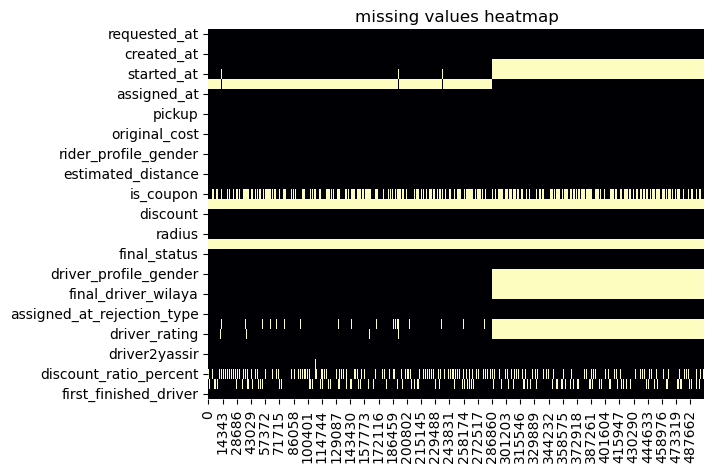

In [27]:
sns.heatmap(data.isna().T, cbar=False, cmap='magma')
plt.title("missing values heatmap")
plt.show()

### Répartition du statut final des trajets

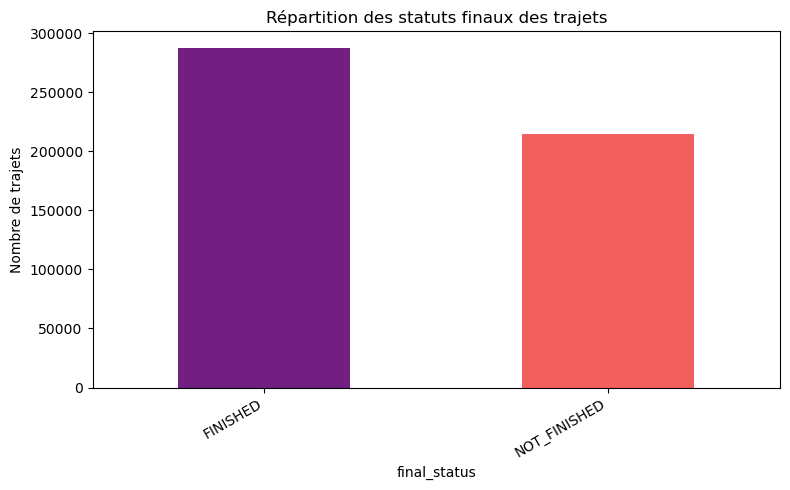

In [28]:
plt.figure(figsize=(8, 5))
data['final_status'].value_counts().plot(kind='bar', color=sns.color_palette("magma", data['final_status'].nunique()))
plt.title("Répartition des statuts finaux des trajets")
plt.ylabel("Nombre de trajets")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

> Le statut final (`FINISHED`, `DRIVER_CANCELED`, `DRIVER_CANCELED_TIMEOUT`, etc.) détermine si le chauffeur assigné a effectivement complété le trajet — c'est la base de la variable cible construite en Section B.

### Relations entre variables numériques clés

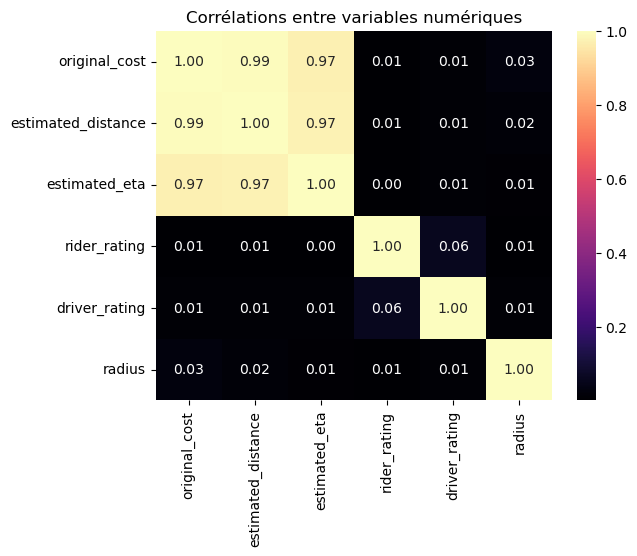

In [29]:
num_cols = ['original_cost', 'estimated_distance', 'estimated_eta',
            'rider_rating', 'driver_rating', 'radius']
sns.heatmap(data[num_cols].corr(), annot=True, fmt='.2f', cmap='magma')
plt.title("Corrélations entre variables numériques")
plt.show()

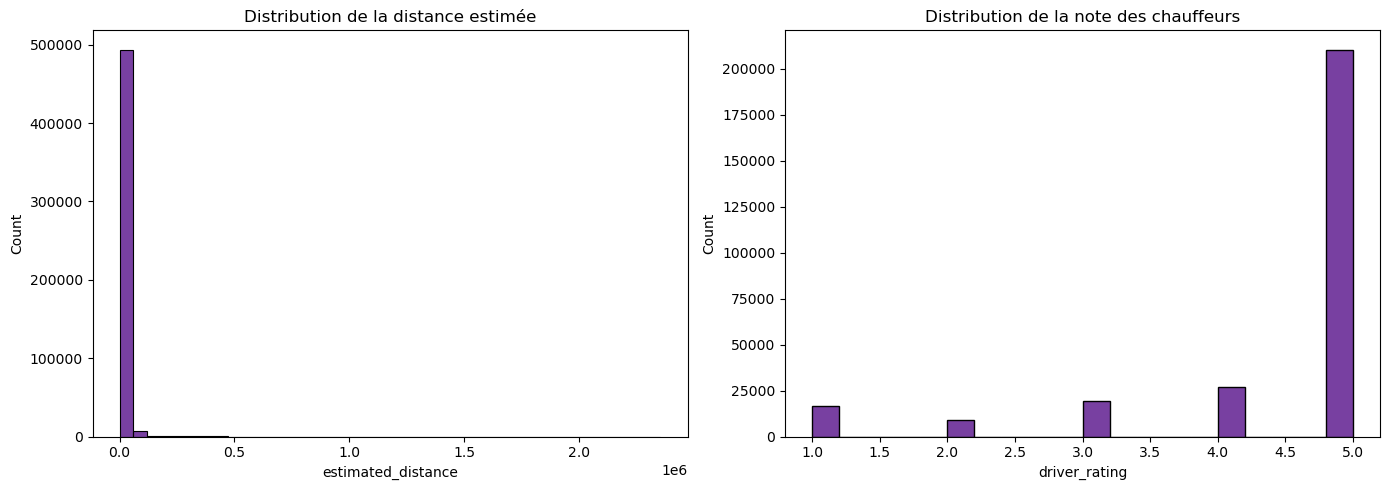

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data['estimated_distance'], bins=40, ax=axes[0], color='indigo')
axes[0].set_title("Distribution de la distance estimée")
sns.histplot(data['driver_rating'].dropna(), bins=20, ax=axes[1], color='indigo')
axes[1].set_title("Distribution de la note des chauffeurs")
plt.tight_layout()
plt.show()

# Section B: Feature Engineering

**Idée générale :** pour chaque trajet, on dispose d'un chauffeur *assigné* (`assigined_driver`) et d'un chauffeur *final* (`final_driver`) qui a effectivement complété le trajet — ils peuvent être identiques ou différents (réassignation). On construit un jeu de données au format **(trajet, chauffeur candidat)** avec une cible binaire indiquant si ce chauffeur candidat est celui qui a complété le trajet. Ce format permet d'entraîner un modèle de classification, puis de l'utiliser pour **classer** les chauffeurs candidats d'un trajet par probabilité décroissante (ranking).

In [31]:
# ligne "positive" : le chauffeur qui a réellement complété le trajet (target = 1 par construction)
add_row = data[["trip_id", "final_driver", "final_driver"]].drop_duplicates()
add_row.columns = ["trip_id", "assigined_driver", "final_driver"]

# ligne "observée" : le chauffeur initialement assigné au trajet
row = data[["trip_id", "assigined_driver", "final_driver"]]

# concaténation : chaque trajet apparaît avec son chauffeur assigné ET son chauffeur final
fin_con = pd.concat([add_row, row], axis=0, ignore_index=True)
fin_con = fin_con.sort_values(["trip_id"])

In [32]:
# variable cible : le chauffeur candidat est-il celui qui a complété le trajet ?
fin_con["target"] = (fin_con["assigined_driver"] == fin_con["final_driver"]).astype(int)
fin_con["target"].value_counts(normalize=True)

target
0    0.779208
1    0.220792
Name: proportion, dtype: float64

### Variables agrégées par chauffeur

In [33]:
# taux de complétion par chauffeur (% de trajets terminés)
taux_completion = data.groupby('assigined_driver').apply(
    lambda x: (x['final_status'] == 'FINISHED').mean()
).to_dict()

# note moyenne des chauffeurs
note_moyenne = data.groupby('assigined_driver')['driver_rating'].mean().to_dict()

# nombre de trajets effectués par chauffeur
nb_trajets = data.groupby('assigined_driver')['trip_id'].count().to_dict()

# distance moyenne parcourue par chauffeur
distance_moyenne = data.groupby('assigined_driver')['estimated_distance'].mean().to_dict()

# taux d'annulation par le chauffeur
taux_annulation = data.groupby('assigined_driver').apply(
    lambda x: (x['final_status'] == 'CANCELLED_BY_DRIVER').mean()
    if 'CANCELLED_BY_DRIVER' in x['final_status'].values else 0
).to_dict()

C:\Users\SOL\AppData\Local\Temp\ipykernel_1248\1562561583.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  taux_completion = data.groupby('assigined_driver').apply(
C:\Users\SOL\AppData\Local\Temp\ipykernel_1248\1562561583.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  taux_annulation = data.groupby('assigined_driver').apply(


### Variables propres au trajet

In [34]:
distance_trajet = data.set_index('trip_id')['estimated_distance'].to_dict()
cout_trajet = data.set_index('trip_id')['original_cost'].to_dict()
statut_trajet = data.set_index('trip_id')['final_status'].to_dict()
est_reserve = data.set_index('trip_id')['is_booked'].to_dict()

In [35]:
# application des variables au dataset (trajet, chauffeur candidat)
fin_con['taux_completion'] = fin_con['assigined_driver'].map(taux_completion)
fin_con['note_moyenne'] = fin_con['assigined_driver'].map(note_moyenne)
fin_con['nb_trajets'] = fin_con['assigined_driver'].map(nb_trajets)
fin_con['distance_moyenne'] = fin_con['assigined_driver'].map(distance_moyenne)
fin_con['taux_annulation'] = fin_con['assigined_driver'].map(taux_annulation)

fin_con['distance_trajet'] = fin_con['trip_id'].map(distance_trajet)
fin_con['cout_trajet'] = fin_con['trip_id'].map(cout_trajet)
fin_con['statut_trajet'] = fin_con['trip_id'].map(statut_trajet)
fin_con['est_reserve'] = fin_con['trip_id'].map(est_reserve)

fin_con.head()

,trip_id,assigined_driver,final_driver,target,taux_completion,note_moyenne,nb_trajets,distance_moyenne,taux_annulation,distance_trajet,cout_trajet,statut_trajet,est_reserve
146287,gAAAAABnP1ef--3vFfAOJgEf3-RyA9pTm-pfjWAGOxkXhj...,gAAAAABnP1ePSUralyqcKVNakVKyfpgqvUXUzpZ6gm_5aQ...,gAAAAABnP1ePtCB-IqV5JTijXkgcUUSl3bhYQQ-WljKidI...,0,0.740488,4.471448,1025.0,8330.177561,0.0,1315,-0.499668,FINISHED,False
3923,gAAAAABnP1ef--3vFfAOJgEf3-RyA9pTm-pfjWAGOxkXhj...,gAAAAABnP1ePtCB-IqV5JTijXkgcUUSl3bhYQQ-WljKidI...,gAAAAABnP1ePtCB-IqV5JTijXkgcUUSl3bhYQQ-WljKidI...,1,0.916667,4.636364,36.0,17195.388889,0.0,1315,-0.499668,FINISHED,False
308415,gAAAAABnP1ef--3vFfAOJgEf3-RyA9pTm-pfjWAGOxkXhj...,gAAAAABnP1ePFrk96bEft8WGJTStDS5zCx96HLHiNZ-2k8...,gAAAAABnP1ePtCB-IqV5JTijXkgcUUSl3bhYQQ-WljKidI...,0,0.550588,4.478632,425.0,11556.192941,0.0,1315,-0.499668,FINISHED,False
142798,gAAAAABnP1ef--EdzL71VHQj_5jyOpFGhS2KpI5B95s-k5...,gAAAAABnP1eTMKGDLYvfynTB6KpwRB5-STMOOFTdrlaSN5...,gAAAAABnP1ePSIWNOo5ldpsuJccvLMMixqQ3sUHweqYgak...,0,0.647059,4.200000,17.0,8520.470588,0.0,10928,0.074419,FINISHED,False
559,gAAAAABnP1ef--EdzL71VHQj_5jyOpFGhS2KpI5B95s-k5...,gAAAAABnP1ePSIWNOo5ldpsuJccvLMMixqQ3sUHweqYgak...,gAAAAABnP1ePSIWNOo5ldpsuJccvLMMixqQ3sUHweqYgak...,1,0.612403,4.437299,516.0,11852.686047,0.0,10928,0.074419,FINISHED,False


In [40]:
fin_con['est_reserve'] = fin_con['trip_id'].map(est_reserve)
fin_con['est_reserve'] = fin_con['est_reserve'].astype(str)   # <-- ajouter cette ligne

## Split train / validation par groupe de trajet

Les deux lignes générées pour un même `trip_id` (chauffeur assigné + chauffeur final) doivent rester **dans le même split** — sinon le modèle pourrait "voir" indirectement un trajet du jeu de validation pendant l'entraînement. On utilise donc un `GroupShuffleSplit` groupé par `trip_id`, plutôt qu'un simple `train_test_split` aléatoire.

In [41]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=123)
train_idx, val_idx = next(splitter.split(fin_con, groups=fin_con["trip_id"]))

train = fin_con.iloc[train_idx].copy()
val = fin_con.iloc[val_idx].copy()

print(f"Trajets en train : {train['trip_id'].nunique()} | Trajets en val : {val['trip_id'].nunique()}")

Trajets en train : 106677 | Trajets en val : 35559


# Section C: Machine Learning Modeling with OOP

In [42]:
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

### Le prétraitement des données

In [43]:
features = ['taux_completion', 'note_moyenne', 'nb_trajets', 'distance_moyenne',
            'taux_annulation', 'distance_trajet', 'cout_trajet', 'est_reserve']

x_train = train[features]
y_train = train["target"]
x_val = val[features]
y_val = val["target"]

In [44]:
colomn_num = make_column_selector(dtype_include=np.number)
colomn_cat = make_column_selector(dtype_exclude=np.number)

num_tran = make_pipeline(SimpleImputer(strategy="mean"), StandardScaler())
cat_tran = make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown='ignore'))

prepros = make_column_transformer((num_tran, colomn_num),
                                   (cat_tran, colomn_cat))

X_train_tr = prepros.fit_transform(x_train)
X_val_tr = prepros.transform(x_val)

### Classe `ML_model`

Encapsule l'entraînement, l'évaluation en classification (accuracy, F1, ROC AUC) **et** l'évaluation en ranking via le **Mean Reciprocal Rank (MRR)** — la métrique officielle du challenge — calculée en regroupant les probabilités prédites par `trip_id` sur le jeu de validation.

In [45]:
class ML_model:
    def __init__(self, model, name="MLmodel"):
        self.model = model
        self.name = name

    def fit_train(self, X_train, y_train):
        print(f"Entraînement du modèle {self.name}")
        self.model.fit(X_train, y_train)

    def evaluate(self, X_val, y_val):
        y_pred = self.model.predict(X_val)
        y_proba = self.model.predict_proba(X_val)[:, 1]

        acc = accuracy_score(y_val, y_pred)
        f_one = f1_score(y_val, y_pred, average='macro')
        roc = roc_auc_score(y_val, y_proba)

        print(f"Accuracy {self.name} : {acc:.3f}")
        print(f"F1 Score (macro) {self.name} : {f_one:.3f}")
        print(f"ROC AUC {self.name} : {roc:.3f}")
        print(classification_report(y_val, y_pred))
        return acc, f_one, roc, y_proba

    def evaluate_mrr(self, val_df, y_proba, id_col='trip_id', target_col='target'):
        """Calcule le Mean Reciprocal Rank (métrique officielle du challenge) sur le jeu de validation.
        Pour chaque trip_id, on classe les chauffeurs candidats par probabilité décroissante,
        puis on prend l'inverse du rang du véritable chauffeur (target == 1)."""
        tmp = val_df[[id_col, target_col]].copy()
        tmp['proba'] = y_proba
        tmp = tmp.sort_values([id_col, 'proba'], ascending=[True, False])
        tmp['rank'] = tmp.groupby(id_col).cumcount() + 1

        correct = tmp[tmp[target_col] == 1].copy()
        correct['reciprocal_rank'] = 1 / correct['rank']
        mrr = correct['reciprocal_rank'].mean()
        print(f"MRR (validation) {self.name} : {mrr:.3f}")
        return mrr

    def plot_feature_importance(self, feature_names=None):
        """Affiche l'importance des features pour les modèles qui le supportent"""
        if hasattr(self.model, 'feature_importances_'):
            importances = self.model.feature_importances_
            if feature_names is None:
                feature_names = [f'Feature_{i}' for i in range(len(importances))]
            importance_df = pd.DataFrame({
                'feature': feature_names,
                'importance': importances
            }).sort_values('importance', ascending=True)

            plt.figure(figsize=(10, 6))
            plt.barh(importance_df['feature'], importance_df['importance'])
            plt.xlabel('Importance')
            plt.title(f'Feature Importance - {self.name}')
            plt.tight_layout()
            plt.show()
        else:
            print(f"Le modèle {self.name} ne supporte pas l'affichage de l'importance des features")

### Modèles comparés

On compare trois modèles 

In [46]:
model_1 = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=123)

model_2 = XGBClassifier(n_estimators=400, learning_rate=0.3, max_depth=18,
                         eval_metric='logloss', random_state=123)

model_3 = LGBMClassifier(n_estimators=300, learning_rate=0.1, max_depth=12,
                          verbose=-1, random_state=123)

models = [
    ML_model(model_1, "Random Forest"),
    ML_model(model_2, "XGBoost"),
    ML_model(model_3, "LightGBM"),
]

In [47]:
# Entraînement, évaluation classification + ranking (MRR)
résultat = {
    'model_names': [],
    'accuracy': [],
    'f1_score': [],
    'roc_auc': [],
    'mrr': []
}

for model in models:
    print("==" * 20, f" modèle {model.name} ", "==" * 20)
    model.fit_train(X_train_tr, y_train)
    acc, f_one, roc, y_proba = model.evaluate(X_val_tr, y_val)
    mrr = model.evaluate_mrr(val, y_proba)
    print("-" * 50, "\n")

    résultat['model_names'].append(model.name)
    résultat['accuracy'].append(acc)
    résultat['f1_score'].append(f_one)
    résultat['roc_auc'].append(roc)
    résultat['mrr'].append(mrr)

========================================  modèle Random Forest  ========================================
Entraînement du modèle Random Forest
Accuracy Random Forest : 0.853
F1 Score (macro) Random Forest : 0.707
ROC AUC Random Forest : 0.816
              precision    recall  f1-score   support

           0       0.84      1.00      0.91    126326
           1       0.98      0.34      0.50     35559

    accuracy                           0.85    161885
   macro avg       0.91      0.67      0.71    161885
weighted avg       0.87      0.85      0.82    161885

MRR (validation) Random Forest : 0.820
-------------------------------------------------- 

========================================  modèle XGBoost  ========================================
Entraînement du modèle XGBoost
Accuracy XGBoost : 0.831
F1 Score (macro) XGBoost : 0.725
ROC AUC XGBoost : 0.815
              precision    recall  f1-score   support

           0       0.86      0.93      0.90    126326
           1      

c:\Users\SOL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\SOL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy LightGBM : 0.854
F1 Score (macro) LightGBM : 0.716
ROC AUC LightGBM : 0.833
              precision    recall  f1-score   support

           0       0.85      0.99      0.91    126326
           1       0.95      0.36      0.52     35559

    accuracy                           0.85    161885
   macro avg       0.90      0.68      0.72    161885
weighted avg       0.87      0.85      0.83    161885

MRR (validation) LightGBM : 0.834
-------------------------------------------------- 



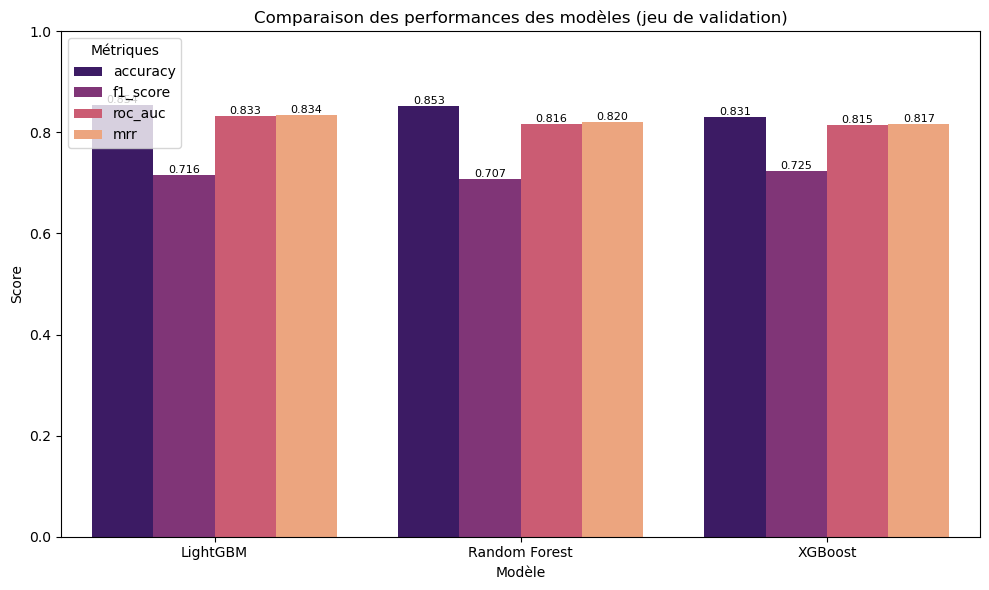

In [48]:
# graphique comparatif des résultats
res = pd.DataFrame(résultat).sort_values('mrr', ascending=False)

res_melted = res.melt(id_vars=['model_names'],
                       value_vars=['accuracy', 'f1_score', 'roc_auc', 'mrr'],
                       var_name='metric', value_name='score')

plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='model_names', y='score', hue='metric', data=res_melted, palette="magma")
for container in barplot.containers:
    barplot.bar_label(container, fmt='%.3f', fontsize=8)

plt.title('Comparaison des performances des modèles (jeu de validation)')
plt.xlabel('Modèle')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='Métriques')
plt.tight_layout()
plt.show()

> ### Les trois modèles sont très proches en performance globale

# Section D: Interpretation & Recommendations

========================================  Feature Importance pour Random Forest  ======================================== 



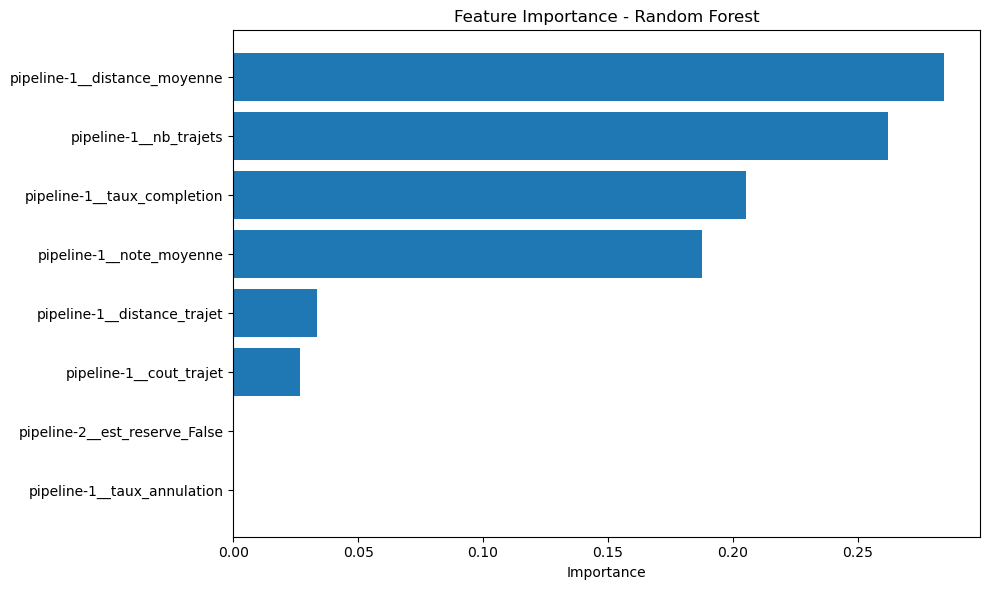



========================================  Feature Importance pour XGBoost  ======================================== 



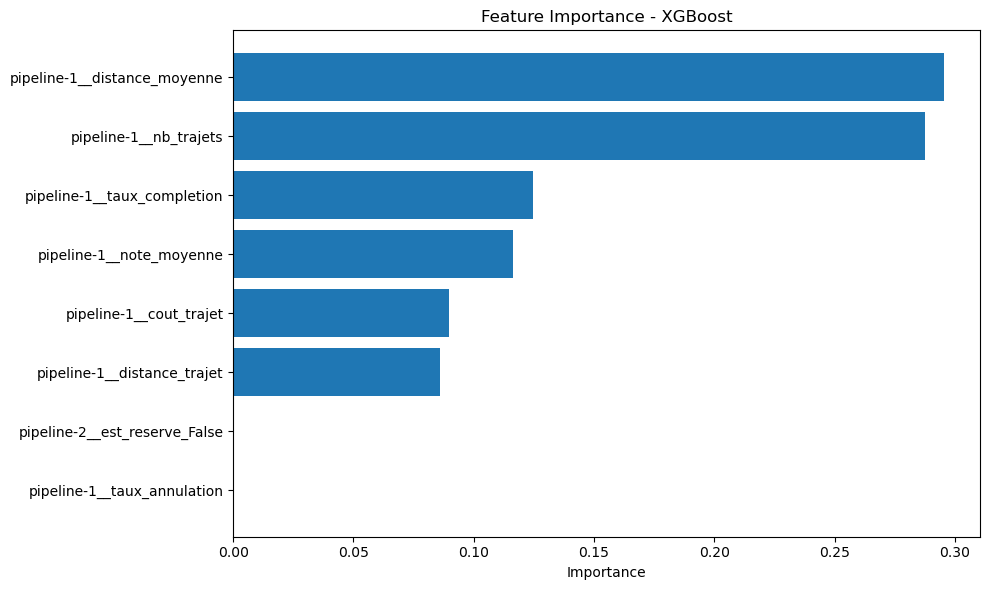



========================================  Feature Importance pour LightGBM  ======================================== 



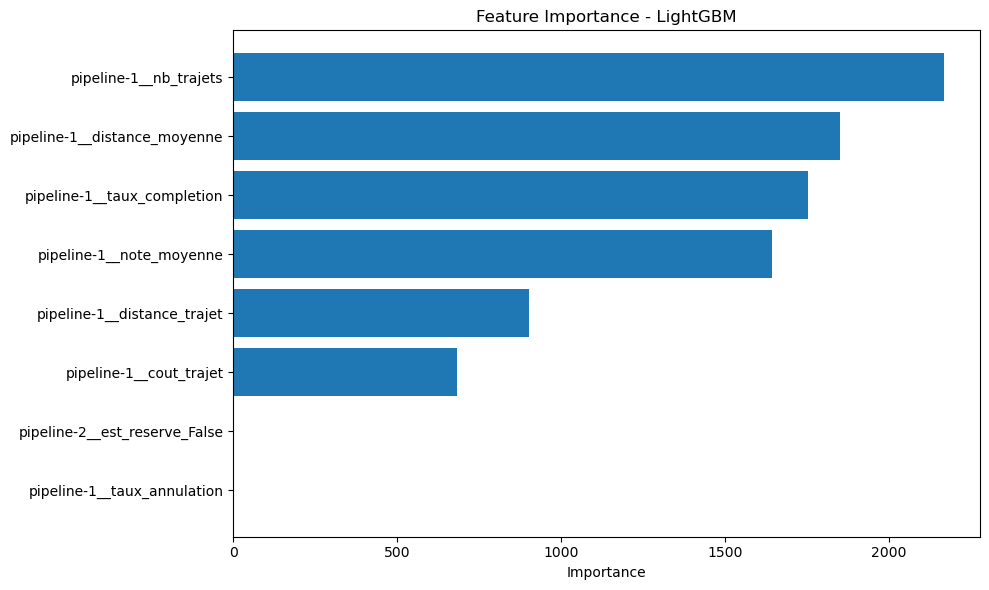

In [49]:
feature_names_transformed = prepros.get_feature_names_out()

for model in models:
    print("==" * 20, f" Feature Importance pour {model.name} ", "==" * 20, "\n")
    model.plot_feature_importance(feature_names=feature_names_transformed)
    print("\n")

## Interprétation et recommandations



### Résultats (jeu de validation)

| Modèle | Accuracy | F1 (macro) | ROC AUC | MRR |
|---|---|---|---|---|
| LightGBM | 0.853 | 0.716 | 0.833 | **0.834** |
| Random Forest | 0.853 | 0.707 | 0.816 | 0.820 |
| XGBoost | 0.831 | **0.725** | 0.815 | 0.817 |

Les trois modèles sont désormais très proches (MRR entre 0.817 et 0.834), avec un léger avantage pour **LightGBM** sur la métrique officielle du challenge (MRR). Les scores ont naturellement baissé par rapport à la version avec `statut_trajet` (MRR ~0.82-0.83 vs jusqu'à 0.891 de ROC AUC avant) — c'est attendu et sain : on mesure maintenant la performance **réellement atteignable au moment de l'assignation**, sans fuite d'information.

### Variables les plus discriminantes

Les trois modèles s'accordent maintenant sur un même classement de variables, ce qui renforce la confiance dans ces résultats :

1. **`distance_moyenne`** et **`nb_trajets`** arrivent systématiquement en tête — l'expérience du chauffeur (nombre de trajets réalisés) et son profil de distance habituel sont les signaux les plus forts pour prédire s'il complétera le trajet assigné.
2. **`taux_completion`** et **`note_moyenne`** suivent de près — la fiabilité historique et la satisfaction rider restent des indicateurs solides, cohérents avec l'intuition métier.
3. **`distance_trajet`** et **`cout_trajet`** (caractéristiques propres au trajet, pas au chauffeur) ont un poids nettement plus faible mais non nul.
4. **`taux_annulation`** et **`est_reserve`** ont une importance quasi nulle sur les trois modèles — ce sont des variables candidates à retirer ou à retravailler (peu de variance dans les données, ou peu discriminantes pour ce problème précis).

**Conclusion :** ce sont les caractéristiques du **chauffeur** (expérience, fiabilité, note) qui dominent très largement sur celles du trajet — une stratégie de matching centrée chauffeur est donc mieux justifiée par les données qu'une stratégie centrée trajet.

### Lecture du MRR

Un MRR de 0.834 (LightGBM) signifie que, sur l'ensemble des trajets de validation, le bon chauffeur est classé en moyenne autour de la 1ère position dans la grande majorité des cas (avec seulement 2 candidats par trajet dans ce jeu de validation, un MRR de 0.5 correspondrait à un classement aléatoire — on en est donc loin, ce qui est encourageant). Il reste toutefois de la marge : un MRR parfait de 1.0 signifierait que le modèle classe systématiquement le bon chauffeur en tête.
